In [1]:
# import libraries
import pandas as pd #for data handling
import numpy as np #numerical operations

#visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

In [3]:
#ML models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [4]:
#Recommendation libraries
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer

In [5]:
# Load dataset

data = pd.read_csv("data.csv", encoding='ISO-8859-1')
data = data.head(1500)
# display first 5 rows
data.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [6]:
# checking dataset information
# number of rows, column types, missing values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    1500 non-null   object 
 1   StockCode    1500 non-null   object 
 2   Description  1499 non-null   object 
 3   Quantity     1500 non-null   int64  
 4   InvoiceDate  1500 non-null   object 
 5   UnitPrice    1500 non-null   float64
 6   CustomerID   1442 non-null   float64
 7   Country      1500 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 93.9+ KB


In [7]:
#check missing values
data.isnull().sum()

InvoiceNo       0
StockCode       0
Description     1
Quantity        0
InvoiceDate     0
UnitPrice       0
CustomerID     58
Country         0
dtype: int64

In [8]:
# remove missing values
data = data.dropna()

In [9]:
#reset index
data = data.reset_index(drop=True)

In [10]:
#show cleaned data
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1442 entries, 0 to 1441
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    1442 non-null   object 
 1   StockCode    1442 non-null   object 
 2   Description  1442 non-null   object 
 3   Quantity     1442 non-null   int64  
 4   InvoiceDate  1442 non-null   object 
 5   UnitPrice    1442 non-null   float64
 6   CustomerID   1442 non-null   float64
 7   Country      1442 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 90.2+ KB


#Exploratory data analysis (EDA)

#QUANTITY DISTRIBUTION

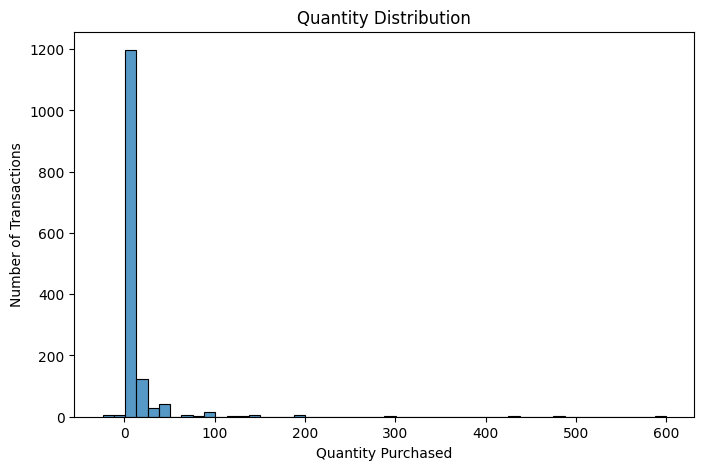

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(data['Quantity'], bins=50)

plt.title("Quantity Distribution")
plt.xlabel("Quantity Purchased")   
plt.ylabel("Number of Transactions")

plt.show()

#TOP COUNTRIES BY ORDERS

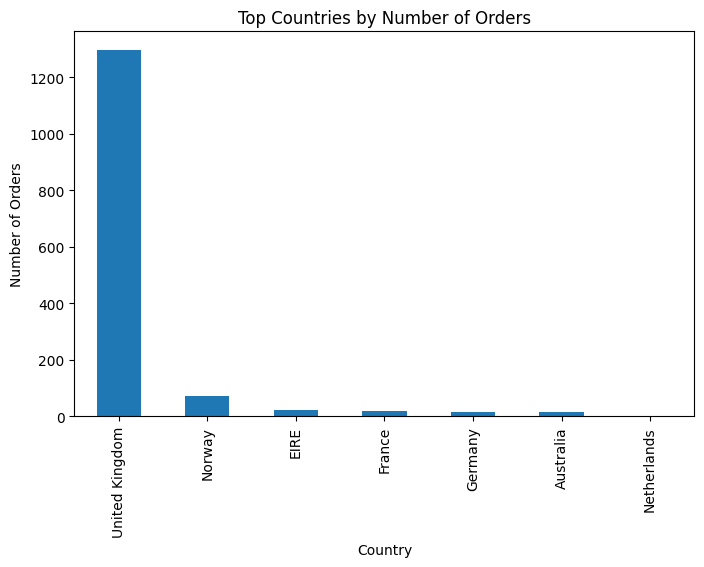

In [13]:
plt.figure(figsize=(8,5))

data['Country'].value_counts().head(10).plot(kind='bar')

plt.title("Top Countries by Number of Orders")
plt.xlabel("Country")
plt.ylabel("Number of Orders")

plt.show()

#PIE CHART- COUNTRY DISTRIBUTION

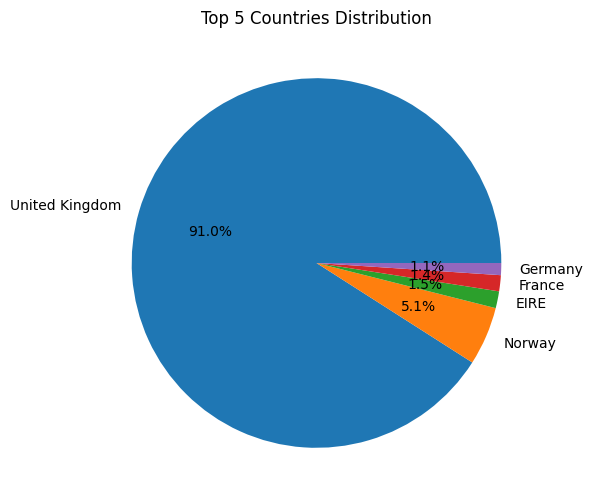

In [14]:
top_countries= data['Country'].value_counts().head(5)

plt.figure(figsize=(6,6))

plt.pie(top_countries, labels=top_countries.index, autopct='%1.1f%%')

plt.title("Top 5 Countries Distribution")

plt.show()

#TOP CUSTOMERS BY PURCHASE

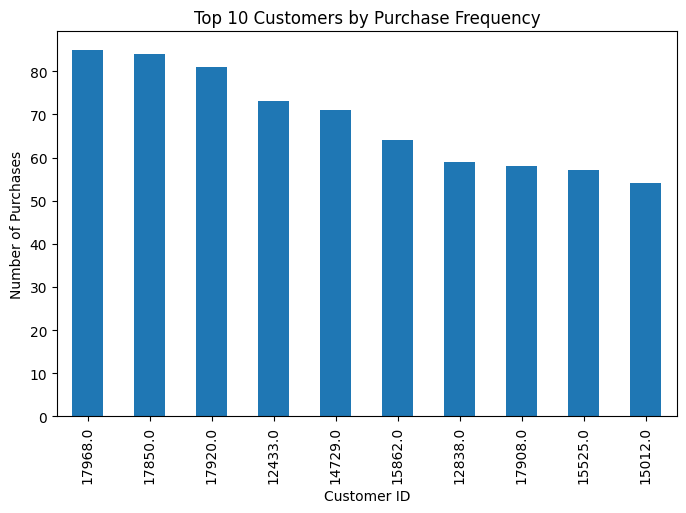

In [15]:
top_customers = data['CustomerID'].value_counts().head(10)

plt.figure(figsize=(8,5))

top_customers.plot(kind='bar')

plt.title("Top 10 Customers by Purchase Frequency")
plt.xlabel("Customer ID")
plt.ylabel("Number of Purchases")

plt.show()

#CONTENT-BASED FILTERING

In [16]:
#remove rows with missing product description
data= data.dropna(subset=['Description'])

In [17]:
#convert columns to string
data['Description']= data['Description'].astype(str)
data['StockCode']= data['StockCode'].astype(str)

In [18]:
data['ProductName']= data['Description']

In [19]:
data_sample=data.head(3000).copy()

In [20]:
#create product features
data_sample['features'] = data_sample['ProductName']+" "+data_sample['StockCode']

In [21]:
cv = CountVectorizer(stop_words='english')

count_matrix = cv.fit_transform(data_sample['features'].head(5000))
#converts text to numbers

In [22]:
#compute similarity
similarity= cosine_similarity(count_matrix)

#ENCODING DATA FOR MACHINE LEARNING

In [23]:
from sklearn.preprocessing import LabelEncoder

le_customer = LabelEncoder()
le_product = LabelEncoder()
le_country = LabelEncoder()

data['CustomerID'] = le_customer.fit_transform(data['CustomerID'])

data['Description'] = le_product.fit_transform(data['Description'])

data['Country'] = le_country.fit_transform(data['Country'])

#CREATE TARGET VARIABLE

In [24]:
#If quantity>0: customer liked the product
data['liked'] = data['Quantity'].apply(lambda x:1 if x>0 else 0)

In [25]:
#SELECT FEATURES
X= data[['CustomerID','Description','Country','UnitPrice']]

y= data['liked']

In [26]:
#Train-test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

#LOGISTIC REGRESSION

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_model= LogisticRegression()

log_model.fit(X_train,y_train)

log_pred= log_model.predict(X_test)

log_accuracy= accuracy_score(y_test, log_pred)

print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.986159169550173


#RANDOM FOREST

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9930795847750865


#Model Comparison Graph

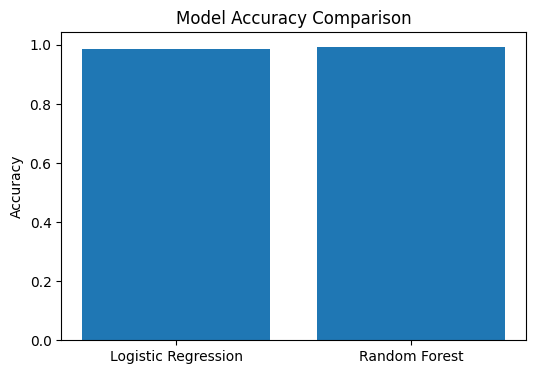

In [29]:
models = ['Logistic Regression','Random Forest']

accuracy= [ log_accuracy, rf_accuracy]

plt.figure(figsize=(6,4))

plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

#Simple Dashboard

In [30]:
print("Total Customers:", data['CustomerID'].nunique())

print("Total Products:", data['Description'].nunique())

print("Average Price:", data['UnitPrice'].mean())

Total Customers: 70
Total Products: 777
Average Price: 3.137295423023578


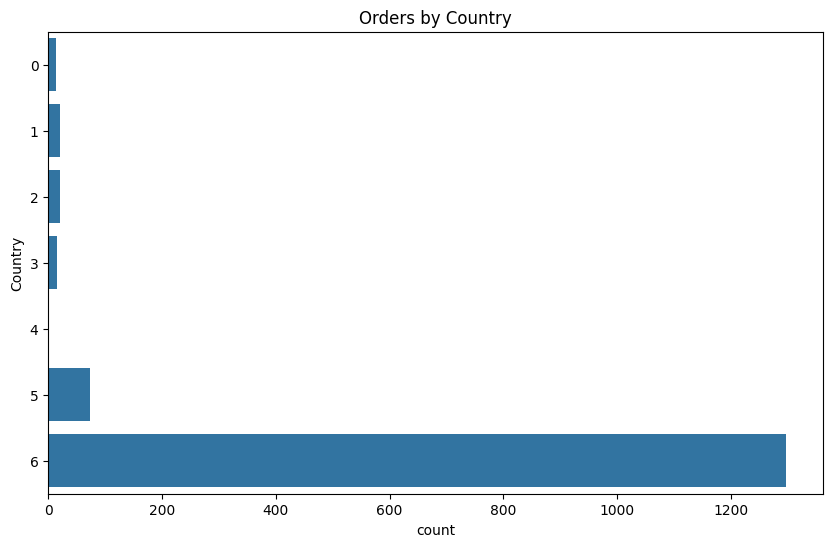

In [31]:
plt.figure(figsize=(10,6))

sns.countplot(y='Country', data=data)

plt.title("Orders by Country")

plt.show()

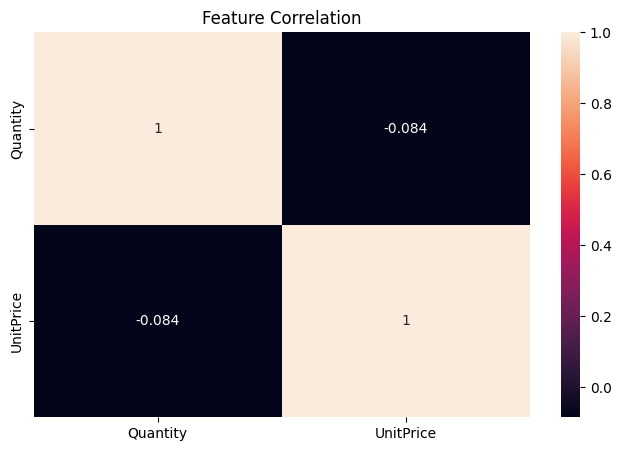

In [32]:
plt.figure(figsize=(8,5))

sns.heatmap(data[['Quantity','UnitPrice']].corr(), annot=True)

plt.title("Feature Correlation")

plt.show()

In [33]:
product_list = data['ProductName'].unique().tolist()

In [34]:
def recommend_products(product_name, top_n=5):
    
    # fast matching from list
    matches = [p for p in product_list if product_name.lower() in p.lower()]
    
    if len(matches) == 0:
        return []
    
    product_name = matches[0]
    
    # get index (FAST)
    product_index = data[data['ProductName'] == product_name].index[0]
    
    # FAST similarity (no full sorting)
    sim_scores = similarity[product_index].argsort()[::-1][1:20]
    
    recommended = []
    
    for i in sim_scores:
        name = data['ProductName'].iloc[i]
        if name not in recommended:
            recommended.append(name)
        if len(recommended) == top_n:
            break
    
    return recommended

In [35]:
recommend_products(data_sample['ProductName'].iloc[200])

['SET OF 3 COLOURED  FLYING DUCKS',
 'SET OF 3 BLACK FLYING DUCKS',
 'SET OF 3 GOLD FLYING DUCKS',
 'COOKING SET RETROSPOT',
 'PAINT YOUR OWN CANVAS SET']

In [36]:
product = data_sample['ProductName'].iloc[300]

print("Selected Product:", product)

recommend_products(product)

Selected Product: BABUSHKA LIGHTS STRING OF 10


['BABUSHKA LIGHTS STRING OF 10',
 'CHRISTMAS LIGHTS 10 REINDEER',
 'CHRISTMAS LIGHTS 10 SANTAS ',
 'CHRISTMAS LIGHTS 10 VINTAGE BAUBLES',
 'SET 10 LIGHTS NIGHT OWL']

In [37]:
data.to_csv("recommendation_data.csv", index=False)

#COLLABORATIVE FILTERING

In [38]:
data = data.dropna(subset=['CustomerID', 'Description', 'Quantity'])

In [39]:
data['CustomerID'] = data['CustomerID'].astype(int)

In [40]:
user_item = data.pivot_table(
    index='CustomerID',
    columns='ProductName',   
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)

In [41]:
print(user_item.columns[:5])

Index([' 4 PURPLE FLOCK DINNER CANDLES', ' SET 2 TEA TOWELS I LOVE LONDON ',
       '10 COLOUR SPACEBOY PEN', '12 DAISY PEGS IN WOOD BOX',
       '12 MESSAGE CARDS WITH ENVELOPES'],
      dtype='object', name='ProductName')


In [42]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

user_sim = cosine_similarity(user_item)

user_sim_df = pd.DataFrame(user_sim,
                          index=user_item.index,
                          columns=user_item.index)

In [43]:
def recommend_collab(user_id, top_n=5):
    
    if user_id not in user_sim_df.index:
        return []
    
    similar_users = user_sim_df[user_id].sort_values(ascending=False)[1:6]
    
    similar_users_data = user_item.loc[similar_users.index]
    
    recommendations = similar_users_data.sum().sort_values(ascending=False)
    
    return list(recommendations.index[:top_n])

In [44]:
recommend_collab(5)  

['HAND WARMER BIRD DESIGN',
 'HAND WARMER SCOTTY DOG DESIGN',
 'ASSORTED COLOUR BIRD ORNAMENT',
 'PACK OF 60 PINK PAISLEY CAKE CASES',
 'PACK OF 72 RETROSPOT CAKE CASES']

In [45]:
def recommend_collab(user_id, top_n=5):
    
    if user_id not in user_sim_df.index:
        return []
    
    similar_users = user_sim_df[user_id].sort_values(ascending=False)[1:6]
    
    similar_users_data = user_item.loc[similar_users.index]
    
    recommendations = similar_users_data.sum().sort_values(ascending=False)
    
    return list(recommendations.index[:top_n])

In [46]:
def hybrid_recommend(product_name, user_id):
    
    content = recommend_products(product_name)
    collab = recommend_collab(user_id)
    
    # handle errors
    if isinstance(content, str):
        content = []
    if isinstance(collab, str):
        collab = []
    
    # combine
    final = content[:3] + collab[:3]
    
    # remove duplicates
    final_unique = []
    for item in final:
        if item not in final_unique:
            final_unique.append(item)
    
    return final_unique

In [47]:
hybrid_recommend("WHITE HANGING HEART T-LIGHT HOLDER", 5)

['WHITE HANGING HEART T-LIGHT HOLDER',
 'HANGING HEART ZINC T-LIGHT HOLDER',
 'RED HANGING HEART T-LIGHT HOLDER',
 'HAND WARMER BIRD DESIGN',
 'HAND WARMER SCOTTY DOG DESIGN',
 'ASSORTED COLOUR BIRD ORNAMENT']

In [48]:
hybrid_recommend("WHITE HANGING HEART T-LIGHT HOLDER", 4048)

['WHITE HANGING HEART T-LIGHT HOLDER',
 'HANGING HEART ZINC T-LIGHT HOLDER',
 'RED HANGING HEART T-LIGHT HOLDER']

In [49]:
hybrid_recommend("CREAM CUPID HEARTS COAT HANGER", 13047)

['CREAM CUPID HEARTS COAT HANGER',
 'DOORMAT HEARTS',
 'FELTCRAFT BUTTERFLY HEARTS']

In [50]:
print("Hybrid Recommendation System")

product = "WHITE HANGING HEART T-LIGHT HOLDER"
user_id = 4048

print("\nInput:")
print("Product:", product)
print("User ID:", user_id)

result = hybrid_recommend(product, user_id)

print("\nRecommended Products:")
for i in result:
    print("-", i)

Hybrid Recommendation System

Input:
Product: WHITE HANGING HEART T-LIGHT HOLDER
User ID: 4048

Recommended Products:
- WHITE HANGING HEART T-LIGHT HOLDER
- HANGING HEART ZINC T-LIGHT HOLDER
- RED HANGING HEART T-LIGHT HOLDER
